<h1 style="font-size: 40px; margin-bottom: 0px;">2.1 Statistical Analysis in Python (I)</h1>

<p style="margin-top: 15px;"><strong>And more plotting</strong></p>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

Today, we'll continue working with the data that we've collected from MCB201A as well as generating some hypothetical datasets to practice working in Python and running statistical analyses. Since today's lesson involves a lot of the skills you know, today will lean more towards independent exercises, since the concepts should be familiar to you from your own prior research experience and MCB201A. Now it is just translating that knowledge into Python code and understanding how our Python interpreter is seeing our data. At set points, we'll reconvene and see where everyone is at and also proceed with a couple of guided demonstrations.

We'll start by analyzing our class MTT data that we've generated a nice swarmplot for. We will first pull out some descriptive statistics from our data and run a quick two-tailed t-test to evaluate if TAZ KO significantly impairs our MDA-MB-231 cells' ability to proliferate. Then, we will update our swarmplot with the results of our analysis and export our finished publication quality figure. You will practice setting up a function to use in subsequent analyses, and you will also learn a couple of ways to begin compacting your code.

<strong>Learning objectives:</strong>
<ul>
    <li>Continue to practice using and defining functions</li>
    <li>Learn methods to calculate descriptive statistics</li>
    <li>Perform pair-wise comparisons between datasets</li>
    <li>Learn more complex assignment operations</li>
    <li>Learn list and dictionary comprehension to compact code</li>
    <li>Additional plotting practice</li>
</ul>

<h2>Import Packages</h2>

<ul>
    <li><code>numpy</code></li>
    <li><code>pandas</code></li>
    <li><code>matplotlib.pyplot</code></li>
    <li><code>seaborn</code> - to fine tune visualizations</li>
    <li><code>scipy.stats</code> - to perform statistical tests</li>
    <li><code>os</code></li>
</ul>

In [64]:
#Import our packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #1 - Analyze class MTT data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

For this exercise, you'll be analyzing your target gene's MTT data, running through a few descriptive statistics then performing a statistical analysis of the data. Once everyone has completed their analysis, we'll proceed with a guided plotting demonsration.

<h2>Import the class MTT data for your target gene from <code>Week_01</code></h2>

Go ahead and first import our class MTT data. You can use the same .csv file that we used last week, so you'll need to specify the file path when importing the file.

In [2]:
#Load in our class yap data for this example
#pulling in the file that we exported last week
mtt_data = pd.read_csv(
    '../Week_01/data/class_mtt_yap_data.csv',
)

Then do a quick sanity check to see if it imported correctly.

In [3]:
mtt_data

,control,yapko
0,1.245023,2.016001
1,0.818574,0.398504
2,1.255742,1.026822
3,0.597438,0.498545
4,1.083223,0.725551


<h2>Calculate the mean relative corrected absorbance of control and TAZ KO</h2>

Recall that the data that we exported was for the relative corrected absorbances. For this part of exercise #1, use <code>pandas</code> <code>pd.DataFrame.mean()</code> function to calculate the means of both the <code>control</code> and the <code>tazko</code> groups. <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.mean()</code> can be found here.</u></a> 

If you dig into the documentation, you can see that you can provide the function with the full DataFrame, and it will calculate mean of all values along a defined axis (either for rows or columns).

In [4]:
#We can calculate the mean like we've done before using pd.mean()
#We operate on the whole DataFrame and use the default axis=0 value
#And we'll get back a Series containing two values
#in this case, we'll get the control mean and the yapko mean

mtt_data.mean()

control    1.000000
yapko      0.933085
dtype: float64

<h2>Calculate the standard deviation and standard error of the mean for both sample groups</h2>

We can similarly use <code>pandas</code> to calculate the standard deviation and standard error of the mean for both groups by supplying it with the full DataFrame. In this case, we'll use the <code>pd.DataFrame.std()</code> and <code>pd.DataFrame.sem()</code> functions. <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.std()</code> can be found here.</u></a> <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sem.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.sem()</code> can be found here.</u></a>

In [5]:
#We can do the same thing using the pd.DataFrame.std() function to calculate standard deviation
mtt_data.std()

control    0.286067
yapko      0.651760
dtype: float64

In [6]:
#Same for the standard error of the mean
mtt_data.sem()

control    0.127933
yapko      0.291476
dtype: float64

<h2>Perform a two-tailed t-test</h2>

We've taken a look at our class MTT data's descriptive statistics, and to determine if there's a significant difference in the means of our two groups, we'll make use of <code>scipy.stats</code>. This package contains a lot of important functions that allow us to perform the statistical tests that we'll often encounter in biomedical research. The one we're all familiar with is the two-tailed t-test that compares the means of two groups.

The function in <code>scipy.stats</code> that allows us to perform a two-tailed t-test is the <code>stats.ttest_ind()</code> function. <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html" rel="noopener noreferrer"><u>Documentation for <code>stats.ttest_ind()</code> can be found here</u></a>.


If we dig into the documentation to see what the function requires from us in order to perform its defined operation:

```python
scipy.stats.ttest_ind(a, b, axis=0, equal_var=True, nan_policy='propagate')
```

We can see that the parameters that you'll need to keep in mind are:
<ul>
    <li><code>a</code> - list or array-like object of your first group of samples. In our case, we can have this be our <code>'control'</code> samples' data.</li>
    <li><code>b</code> - list or array-like object of your second group of samples. This can be our <code>'tazko'</code> samples' data.</li>
    <li><code>axis</code> - specifies axis to perform the test. Our dataset is fairly simple, so we can leave this as the default value.</li>
    <li><code>equal_var</code> - tells Python if you want it to assume equal variance or not. If not assuming equal variance, then it will perform a Welch's t-test</li>
    <li><code>nan_policy</code> - tells Python what to do if it encounters an <code>NaN</code>. Can specify <code>'propagate'</code> to propagate the <code>NaN</code> to the output or <code>'omit'</code> to ignore it in the calculations or <code>'raise'</code> to raise an error when <code>NaN</code> is encountered</li>
</ul>

There's a single output to this function, but keep in mind that this single output has multiple attributes. So you can actually have Python output either the full result or specific attributes of the result of the t-test.
<ul>
    <li><code>result</code> - this is the output. You'll want to save your output to a variable, so you can call up the attributes</li>
    <ul>
        <li><code>statistic</code> - t-statistic used to calculate the p-value. This is an attribute of the result</li>
        <li><code>pvalue</code> - the p-value. This is a second attribute of the result</li>
    </ul>
</ul>

So if you want to find the resulting p-value of your statistical analysis, you can either tell Python to directly pull the <code>pvalue</code> attribute when it does the test. Or you can save the result of the test to a variable, and then have Python output the <code>pvalue</code> attribute.

```python
conclusion = stat.ttest_ind(a, b)
print(conclusion.pvalue)
```

In [7]:
#We can make use of the scipy package's stats module to run statistical analyses
#Here, we'll make use of stats.ttest_ind() to run a two-tailed t-test assuming equal variance

#Since the function returns a single result with multiple attributes, 
#we can save the returned object to a variable
#We can then conveniently pull out its attributes (like p-value or t-statistic)

conclusion = stats.ttest_ind(
    mtt_data.control,
    mtt_data.yapko,
)


#Here, we call up the object and pull out the pvalue attribute,
#which contains the pvalue from the statistical test performed
conclusion.pvalue

0.8387545152664981

<h2>Set up if-else statement to output whether or not there is a significant difference</h2>

For this part of the exercise, see if you can use an if-else statement to have Python output a conclusion based on the results of your two-tailed t-test.

In [8]:
#Since we know we want to us a significance threshold of 0.05,
#we can set up a conditional statement using our threshold
#that will allow us to automate and generalize our code if needed

#Here, we set up a simple if-else statement using our threshold
if conclusion.pvalue < 0.05:
    print('It worked!')
else:
    print("It didn't work")

It didn't work


<h2>What if you wanted to output a specific statement regarding whether the difference is a significant increase or decrease?</h2>

How can we then set up our if-else statement to differentiate between whether there is a significant increase or decrease in our MTT data?

In [9]:
#Here, we'll set up something slightly more complex
#by taking into account not only the significance
#but also the direction of change
#Basically if it is increased or decreased compared to control

#First we pull out the means, which we'll use later for our calculations to determine the direction of difference
control_mean = mtt_data.mean().control
yapko_mean = mtt_data.mean().yapko

#First we can set up a conditional assignment
#this conditional assignment will be determined by whether our control mean is less than our ko mean
#and we can do this in a single line
difference = 'increase' if control_mean < yapko_mean else 'decrease'
#breaking this down, we will have a variable called difference, which will be assigned either 'increase' or 'decrease'
#depending on the condition we specified in the single line if-else statement
#so if the control mean is less than the ko mean, we will assign 'increase' to the variable difference
#and if it isn't, then we will assign the value 'decrease' to the variable

#We can then quantify the extent of the difference
#since we normalized to the control mean, the difference in the mean is also the percent change (since control mean is 1)
quantified = f"{100*(yapko_mean - 1):.2f}" if yapko_mean < control_mean else f"{100*(1-yapko_mean):.2f}"
#breaking this down, we are specifying another conditional assignment
#in this case, the value that is assigned to the variable is dependent on whether the ko mean is greater than the control mean
#if we wanted to, we could also reverse the logic to read like our first conditional assignment
#here, we are assigning a formatted string (indicated by the f" "),
#and we're calculating the percent change (code within the { })
#and formatting that value as a float with 2 decimal places (indicated by the :.2f)

#like with our simpler conditional statement from earlier, here we can add complexity to the output
#so it'll output the direction of change and the percent change and p-value too.
if conclusion.pvalue < 0.05:
    print(f"There is a significant {difference} in proliferation when YAP is knocked out ({quantified}% change, p={conclusion.pvalue:.2f})")
else:
    print(f"There's no significant difference in proliferation when we knock out YAP (p={conclusion.pvalue:.2f})")

There's no significant difference in proliferation when we knock out YAP (p=0.84)


We can reconvene here and once everyone is on the same page, we can proceed with annotating a swarmplot of our class MTT data.

<h1 style="font-size: 40px; margin-bottom: 0px;">Annotate swarmplot with analysis results</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 750px;"></hr>

Now that we have the results of our statistical analysis, we can provide that information in our plot as well, so that the reader knows that a statistical test was performed and what the results of that statistical test was. To do this, we'll overlay lines and text over a swarmplot. And we can continue to make use of the swarmplot code that we used previously and update it to have annotations.

<h2>Plot a bracket using <code>plt.plot()</code></h2>

Recall from before that we can generate line plots using <code>plt.plot()</code>, and we can make use of this function to plot a line that forms our bracket to indicate to the reader which two groups are being compared.

<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html" rel="noopener noreferrer"><u>Documentation for <code>plt.plot()</code> can be found here.</u></a>

How can we make use of this function first to plot a single line spanning our two groups, and then how can we modify this to form a bracket?

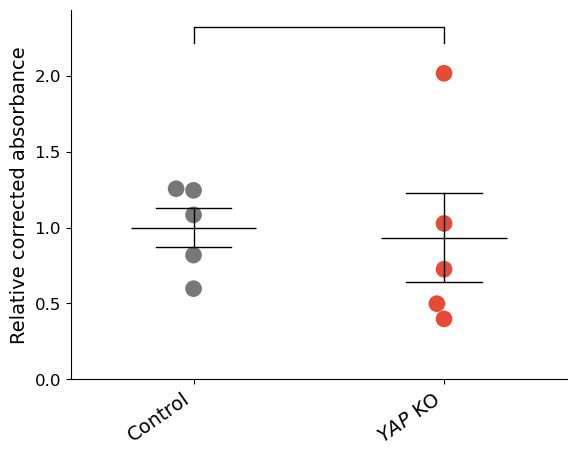

In [10]:
#Here we can take the swarm plot code that we set up previously in 1-2
#and we can then add annotations on top of it

fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)



##########
#Here, we can add in a bracket using plt.plot()
#since the bracket is basically just a line
#plotted with four coordinates

#Specify the 2 x-axis coordinate positions
#Since our ticks are located at 0 and 1, we specify that for x1 and x2, respectively
x1, x2 = 0, 1

#Then we can specify our y-axis coordinates
#We build it up from multiple considerations
#First we want our bracket to be plotted above our largest measurement
y = mtt_data.max().max()
#We use pd.DataFrame.max() to find the max value in the control and in the yapko
#then we use it again to then find the maximum value in our experiment
#hence the .max().max()

#The above will pull the maximum, but we want the bracket to be a little higher than that
adjustment = y*0.1
#here we just multiply by 0.1 to get a small increase proportional to the maximum value
#so it adjusts regardless of the maximum value and is flexible for other datasets too

#We then set a new maximum value to use for plotting our bracket
y_max = y + adjustment

#We specify the height we want for our bracket
#basically how long the legs are for the bracket
h = adjustment*0.5
#Here, we also make it flexible by setting it to half of the adjustment value


#Then we can plot it using plt.plot()
plt.plot(
    [x1, x1, x2, x2],                        #x-axis coordinates, we need four to plot a bracket
    [y_max, y_max + h, y_max + h, y_max],    #y-axis coordinates, paired up to x-axis coordinate by its position in list
    c='k',                                   #set color to be black
    lw=1,                                    #set linewidth to be 1
)
###########

#Fine tune our figures to make it pretty
ax.set_ylabel(
    'Relative corrected absorbance',
    size=14,
)

ax.set_xticks(
    [0,1],
    ['Control', '$YAP$ KO'],
)

plt.yticks(
    size=12,
)

plt.xticks(
    rotation=35,
    ha='right',
    size=14,
)

# fig.set_size_inches(3, 4)

# fig.set_dpi(300)

sns.despine()

plt.show()

# fig.savefig(
#     'class_mtt_yap_swarplot.pdf',
#     bbox_inches='tight',
# )

Now you should see that we have plotted our bracket and adapted our code to be more flexible, so that it is able to adjust accordingly based on the values in our dataset. That way, we don't have to manually go in and replot the brackets if we work with a different dataset.

<h2>Plot text for our annotation using <code>plt.text()</code></h2>

We can also plot text by making use of <code>plt.text()</code>. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html" rel="noopener noreferrer"><u>Documentation for <code>plt.text()</code> can be found here.</u></a>

If we take a look into the documentation:

```python
plt.text(x, y, s, fontdict=None, **kwargs)
```

Breaking this down, we can see the following parameters:

<ul>
    <li><code>x</code> - This is our x-axis position for where we want plot our text.</li>
    <li><code>y</code> - This is our y-axis position for where we want to plot our text.</li>
    <li><code>s</code> - This is a string corresponding to the text that we want to plot.</li>
    <li>Along with additional formatting that can be specified through <code>**kwargs</code>, which are additional keyword arguments. Based on the documentation, using <code>fontdict</code> isn't recommended.</li>
</ul>

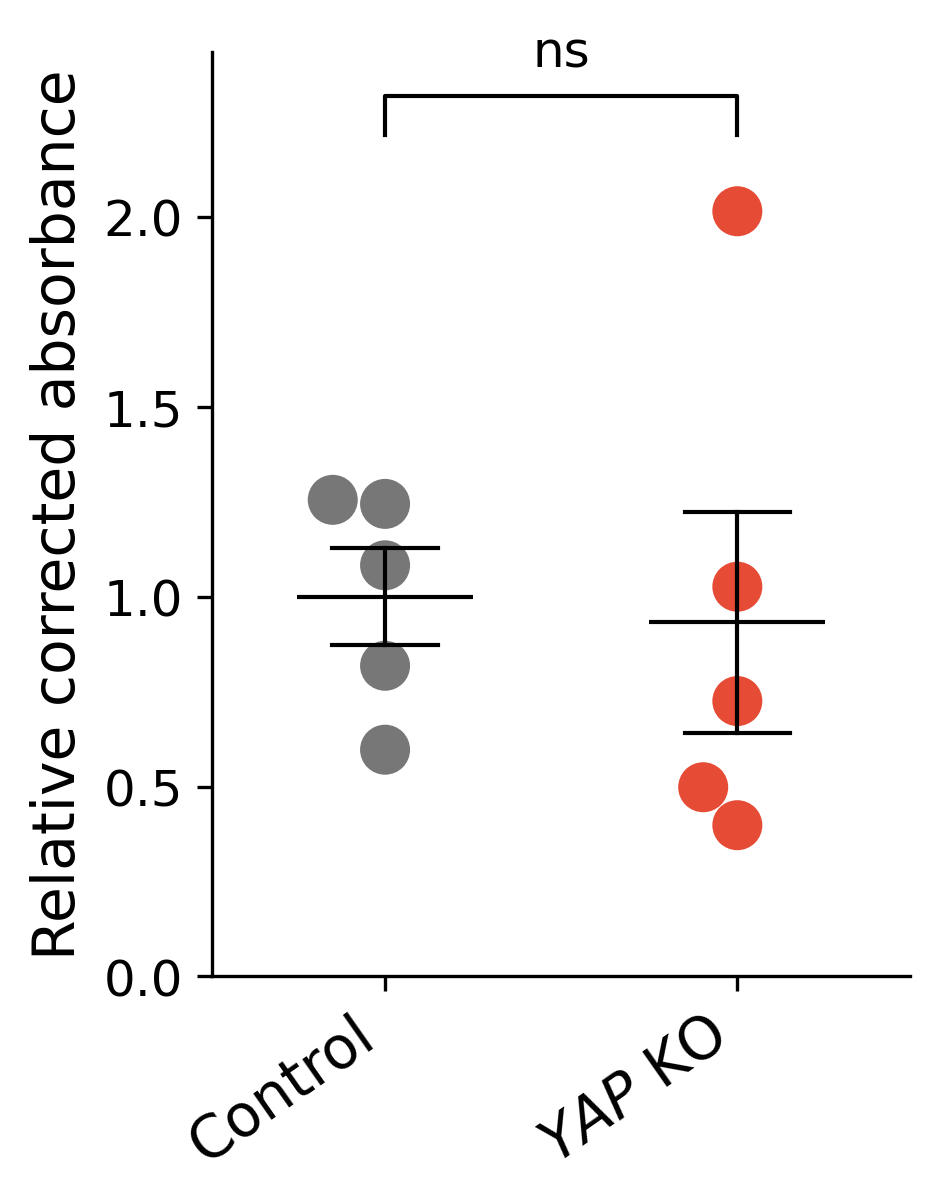

In [11]:
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)


##########
#See plotting bracket section above for detailed breakdown
x1, x2 = 0, 1
y = mtt_data.max().max()
adjustment = y*0.1
y_max = y + adjustment
h = adjustment*0.5

plt.plot(
    [x1, x1, x2, x2],
    [y_max, y_max + h, y_max + h, y_max],
    c='k',
    lw=1,
)
###########

#Here we can make our text flexible
#Set up a conditional assignment based on different significance thresholds
if conclusion.pvalue < 0.0005:
    pvalue_text = '***'
elif conclusion.pvalue < 0.005:
    pvalue_text = '**'
elif conclusion.pvalue < 0.05:
    pvalue_text = '*'
else:
    pvalue_text = 'ns'

#Then we can plot our text above our bracket
plt.text(
    (x1 + x2)*0.5,        #x-axis position for the text will be at the middle of our bracket
    y_max + (h*1.5),      #y-axis position will be just above our bracket
    pvalue_text,          #conditional variable based on assigned value above
    ha='center',          #align the text to the center (so center of text is at middle of the bracket)
    va='bottom',          #have the bottom of the text at our y-axis coordinate
    color='k',            #color of text is set to black
    size=12,              #font size set to 12
)

#Fine tune our figures to make it pretty
ax.set_ylabel(
    'Relative corrected absorbance',
    size=14,
)

ax.set_xticks(
    [0,1],
    ['Control', '$YAP$ KO'],
)

plt.yticks(
    size=12,
)

plt.xticks(
    rotation=35,
    ha='right',
    size=14,
)

fig.set_size_inches(3, 4)

fig.set_dpi(300)

sns.despine()

plt.show()

fig.savefig(
    'class_mtt_yap_swarplot_with_annotation.pdf',
    bbox_inches='tight',
)

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #2 - Set up a function to analyze and visualize data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

As you can see, there's a fair amount of lines of code involved in putting together our swarmplot with descriptive statistics overlaid along with the annotations of our statistical analysis. Since we will be using this method of visualizing our data later in this notebook, we can also set up a function that will generate our desired plot. Moreover, we'd like to also be able to be able to reuse our code to analyze additional datasets.

For this exercise, see if you can put together a function that will run a two-tailed t-test for a general dataset containing 2 columns of data structured like our class data. You function should run through the t-test and then visualize the data as a swarmplot with the overlaid statistics and annotations. You'll want to consider what components are repeated, what can be generalized, and how you can compact the code more.

In [30]:
def swarm_analysis(dataset, y_axislabel, x_ticklabel, figure_name):

    control = dataset.columns[0]
    gene_ko = dataset.columns[1]
    
    conclusion = stats.ttest_ind(
        dataset[control],
        dataset[gene_ko],
        nan_policy='omit',
    )
    
    fig, ax = plt.subplots()

    dot_colors = ['#777777', '#E64B35']
    
    sns.swarmplot(
        data=dataset,
        s=12,
        palette=dot_colors,
        zorder=0,
    )
    
    sns.barplot(
        data=dataset,
        estimator=np.mean,
        alpha=0,
        errorbar='se',
        capsize=0.3,
        err_kws={
            'linewidth': 1,
            'color': 'black',
        },
    )
    
    sns.boxplot(
        data=dataset,
        showmeans=True,
        meanline=True,
        width=0.5,
        meanprops={
            'color': 'black',
            'linestyle': '-',
            'linewidth': 1,
        },
        medianprops={'visible': False},
        whiskerprops={'visible': False},
        showfliers=False,
        showbox=False,
        showcaps=False,
    )
    
    
    ##########
    #See plotting bracket section above for detailed breakdown
    x1, x2 = 0, 1
    y = dataset.max().max()
    adjustment = y*0.1
    y_max = y + adjustment
    h = adjustment*0.5
    
    plt.plot(
        [x1, x1, x2, x2],
        [y_max, y_max + h, y_max + h, y_max],
        c='k',
        lw=1,
    )
    ###########
    
    #Here we can make our text flexible
    #Set up a conditional assignment based on different significance thresholds
    if conclusion.pvalue < 0.0005:
        pvalue_text = '***'
    elif conclusion.pvalue < 0.005:
        pvalue_text = '**'
    elif conclusion.pvalue < 0.05:
        pvalue_text = '*'
    else:
        pvalue_text = 'ns'
    
    #Then we can plot our text above our bracket
    plt.text(
        (x1 + x2)*0.5,        #x-axis position for the text will be at the middle of our bracket
        y_max + (h*1.5),      #y-axis position will be just above our bracket
        pvalue_text,          #conditional variable based on assigned value above
        ha='center',          #align the text to the center (so center of text is at middle of the bracket)
        va='bottom',          #have the bottom of the text at our y-axis coordinate
        color='k',            #color of text is set to black
        size=12,              #font size set to 12
    )
    
    #Fine tune our figures to make it pretty
    ax.set_ylabel(
        y_axislabel,
        size=14,
    )
    
    ax.set_xticks(
        [0,1],
        x_ticklabel,
    )
    
    plt.yticks(
        size=12,
    )
    
    plt.xticks(
        rotation=35,
        ha='right',
        size=14,
    )
    
    # fig.set_size_inches(3, 4)
    
    fig.set_dpi(300)
    
    sns.despine()
    
    plt.show()
    
    fig.savefig(
        f'./{figure_name}_{gene_ko}.pdf',
        bbox_inches='tight',
    )

Now let's give our function a test run on our MTT data and analysis results to see if it can generate the plot as we would expect.

In [13]:
#With our function set up, we can read in our other dataset
#This example will be using TAZ
taz_mtt = pd.read_csv(
    '~/_shared/bcourses-1557888-readonly/temp/class_mtt_data_taz.csv',
)

In [14]:
taz_mtt

,control,tazko
0,1.625869,0.477463
1,0.870458,3.124214
2,1.035828,0.943544
3,2.043409,2.151051
4,0.326353,0.456620
5,0.648867,0.420008
6,0.449215,0.672452


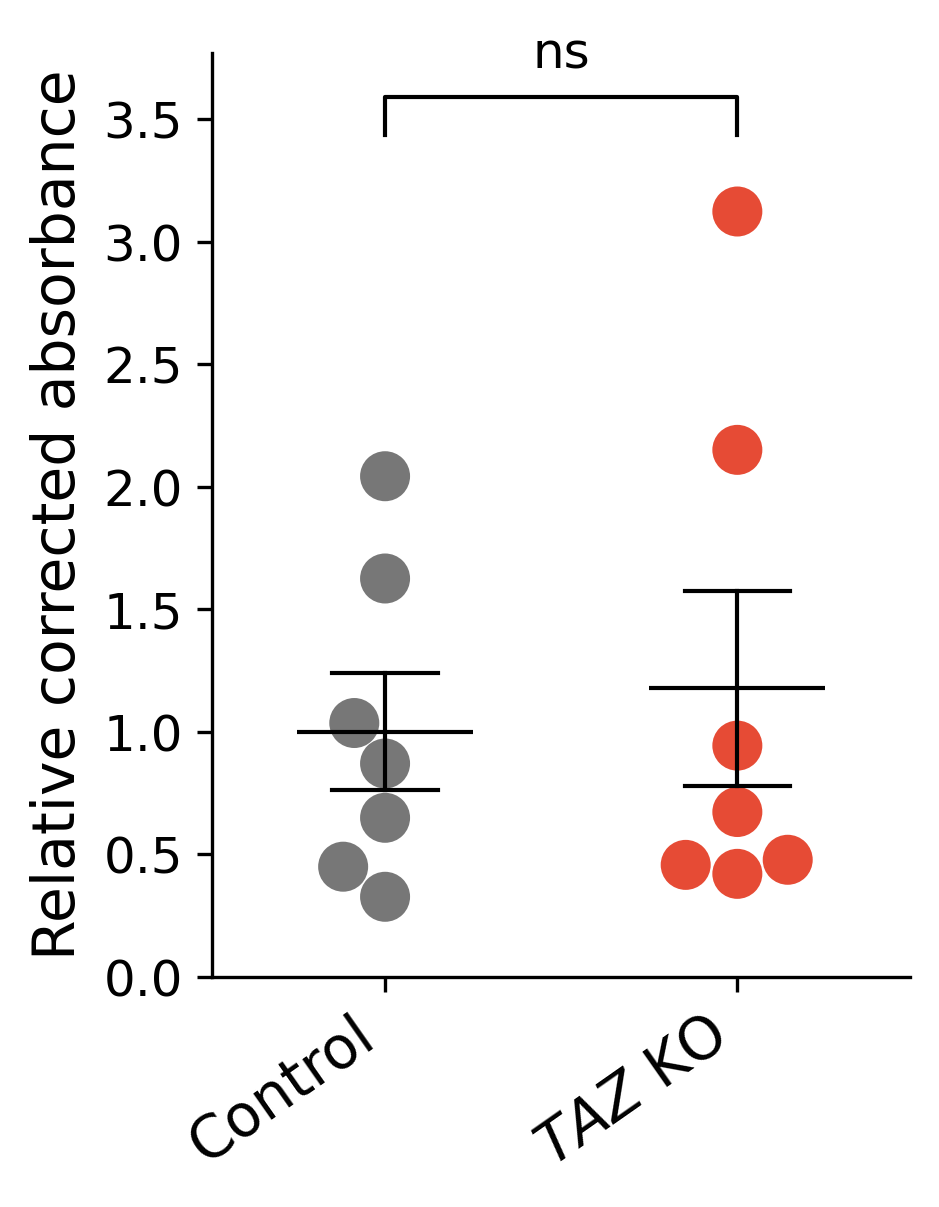

In [17]:
#Copied over how we set up the parameters here just to have it for reference
# swarm_analysis(dataset, y_axislabel, x_ticklabel, figure_name)

#Then we can run our function by calling it up like we would for any other function
swarm_analysis(
    taz_mtt,                            #We provide our dataset
    'Relative corrected absorbance',    #then specify the y axis title
    ['Control', '$TAZ$ KO'],            #and then the x tick labels
    'MTT_swarmplot_analysis',           #and the figure name we want to use for exporting
)

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #3 - Analyze the other gene KO</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

Now give your function a try for a different dataset. In this exercise, pull in the class data for the gene KO that you did not work on, and run your function to run the analysis and get a visualization. 

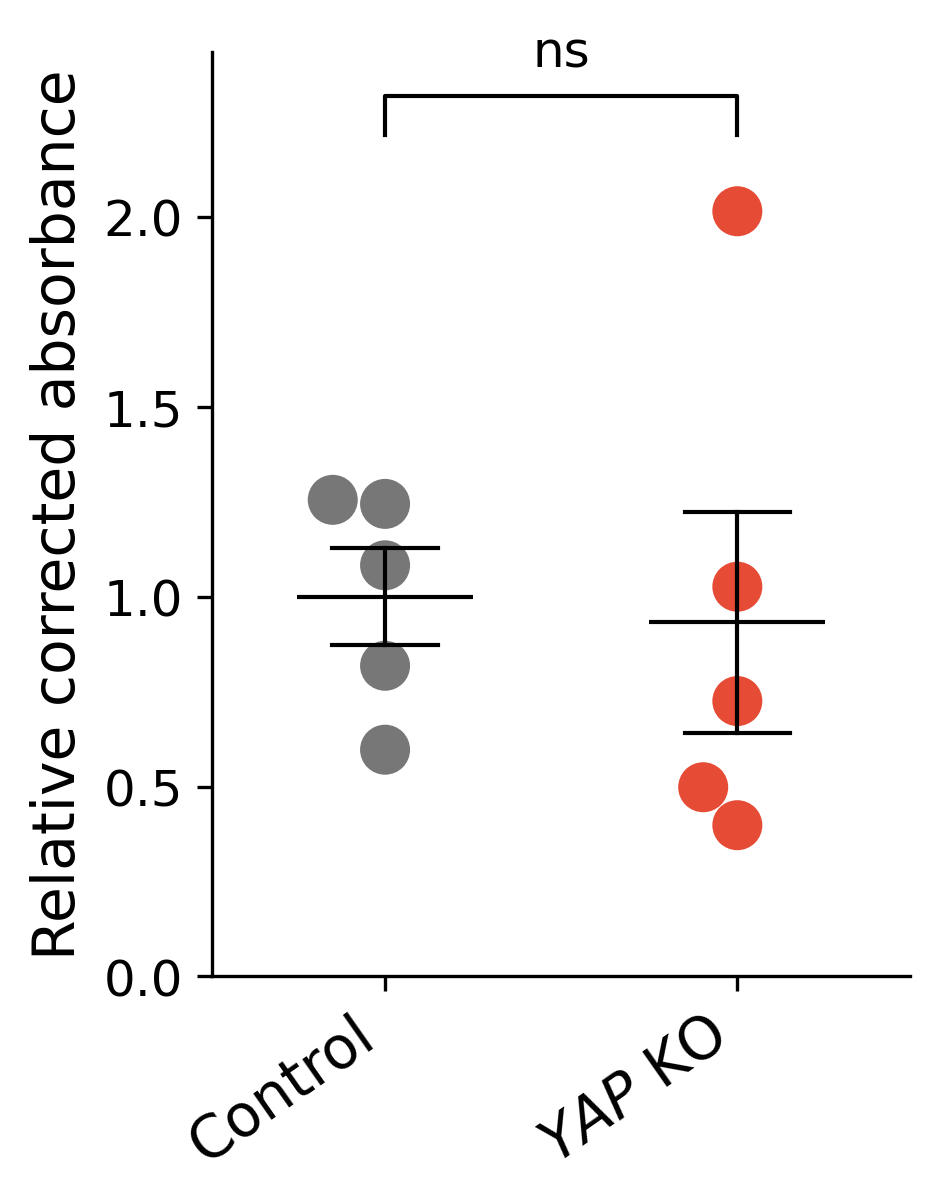

In [18]:
#Since we analyzed TAZ in exercise 2, let's do YAP here which was in our mtt_data variable
swarm_analysis(
    mtt_data, 
    'Relative corrected absorbance',
    ['Control', '$YAP$ KO'],
    'MTT_swarmplot_analysis',
)

#When we run our function, we can then analyze and generate a swarmplot easily for different datasets
#without having to copy over and modify a bunch of lines of code helping to keep things simpler

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #4 - Analyze class xenograft data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

We'll continue practicing statistical analysis by running an analysis on our class xenograft data. In your <code>data</code> folder for this week, you'll find the class xenograft data formatted to be a bit more easily read by Python. 

We can then make use of the function that we defined to readily analyze our data and output the visualization for the different measurements.

<h2>Import <code>class_xenograft_data.csv</code> as a DataFrame</h2>

In [65]:
#Let's apply the function to our xenograft data's quantitative variables
#the volume and the weights

#First read in our xenograft data
tumor_data = pd.read_csv(
    './data/class_xenograft_data.csv',
)

Perform a quick sanity check to see if it imported correctly.

In [66]:
tumor_data

,control_engraftment,control_weight,control_volume,tazko_engraftment,tazko_weight,tazko_volume
0,engraft,0.1390,51.31,engraft,0.0439,31.42
1,engraft,0.0330,6.28,engraft,0.0354,39.27
2,engraft,0.0301,31.42,engraft,0.0870,64.47
3,engraft,0.0120,23.56,engraft,0.0227,5.55
4,engraft,0.0074,10.47,engraft,0.0354,31.42
5,engraft,0.0203,26.18,not_engraft,NaN,NaN
6,engraft,0.0072,3.14,not_engraft,NaN,NaN
7,engraft,0.0957,167.55,not_engraft,NaN,NaN
8,engraft,0.0333,6.28,not_engraft,NaN,NaN
9,engraft,0.0779,43.47,not_engraft,NaN,NaN


You can see the dataset is a bit more complex with columns for different measurements and different types of data as well as containing information for our control and our TAZ KO cells. Additionally,  you can see that for the tumors that did not engraft, their corresponding weight and volume data does not exist and are displayed as <code>nan</code>. For the first part of this exercise, we'll work with our quantitative data.

<h2>Convert weights to mg</h2>

The weight data is currently in grams, so let's do a quick conversion on our original DataFrame to convert the weight measurements from g to mg.

In [67]:
#We can pull out columns based on specific patterns
tumor_data.columns

#So if we're interested in updating the weights, we can pull it based on the presence of the string 'weight'
#essentially pattern matching, where the pattern we're looking for is 'weight'

Index(['control_engraftment', 'control_weight', 'control_volume',
       'tazko_engraftment', 'tazko_weight', 'tazko_volume'],
      dtype='object')

In [68]:
#To set this up, we can loop through all the column labels using a for-loop
for col in tumor_data.columns:
    #And then check to see if they contain the pattern we're looking for
    if 'weight' in col:
        #If it does, then we update the values to convert from g to mg
        tumor_data[col] = tumor_data[col] * 1000
    else:
        #otherwise, if it doesn't we just skip that column
        pass


In [69]:
#Let's check to see how the entire DataFrame looks now after the update
tumor_data

,control_engraftment,control_weight,control_volume,tazko_engraftment,tazko_weight,tazko_volume
0,engraft,139.0,51.31,engraft,43.9,31.42
1,engraft,33.0,6.28,engraft,35.4,39.27
2,engraft,30.1,31.42,engraft,87.0,64.47
3,engraft,12.0,23.56,engraft,22.7,5.55
4,engraft,7.4,10.47,engraft,35.4,31.42
5,engraft,20.3,26.18,not_engraft,NaN,NaN
6,engraft,7.2,3.14,not_engraft,NaN,NaN
7,engraft,95.7,167.55,not_engraft,NaN,NaN
8,engraft,33.3,6.28,not_engraft,NaN,NaN
9,engraft,77.9,43.47,not_engraft,NaN,NaN


<h2>Analyze quantitative xenograft tumor data</h2>

Let's first analyze our weight data now that we've converted the weights to mg. Given your full xenograft dataset, consider how you could then pass your data to your function to analyze and generate an output. 

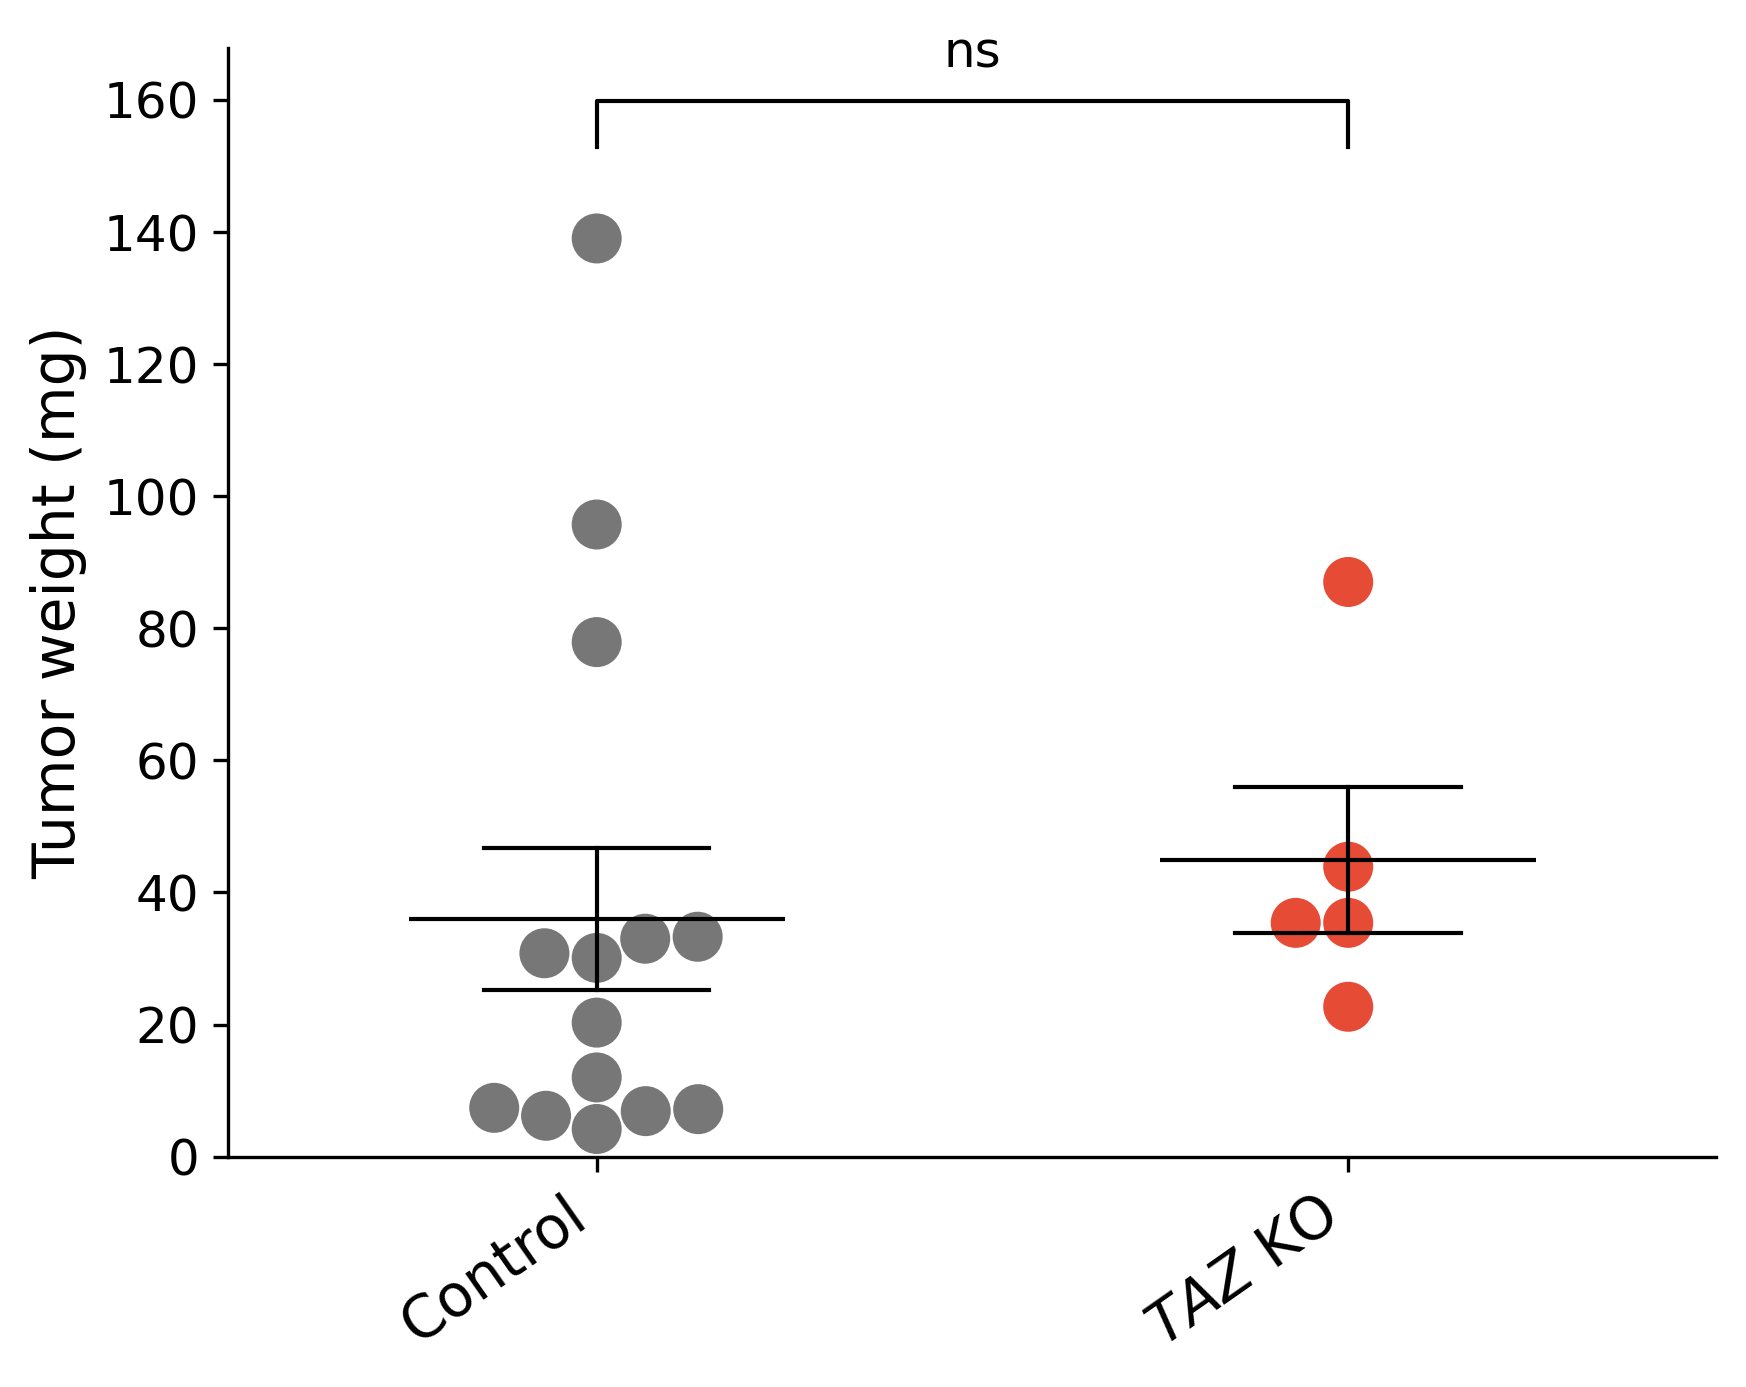

In [70]:
#Then let's analyze the weights as mg using the function we set up
#Here, we call up each parameter by its name to assign a specific value to them
swarm_analysis(
    dataset=tumor_data[['control_weight', 'tazko_weight']],  #since our function takes a DataFrame with 2 columns, we subset our DataFrame
    y_axislabel='Tumor weight (mg)', 
    x_ticklabel=['Control', '$TAZ$ KO'], 
    figure_name='Xenograft_tumor_weight_analysis',
)

Once you've analyzed the xenograft weight data, do the same for the volumes, which were in cubic mm.

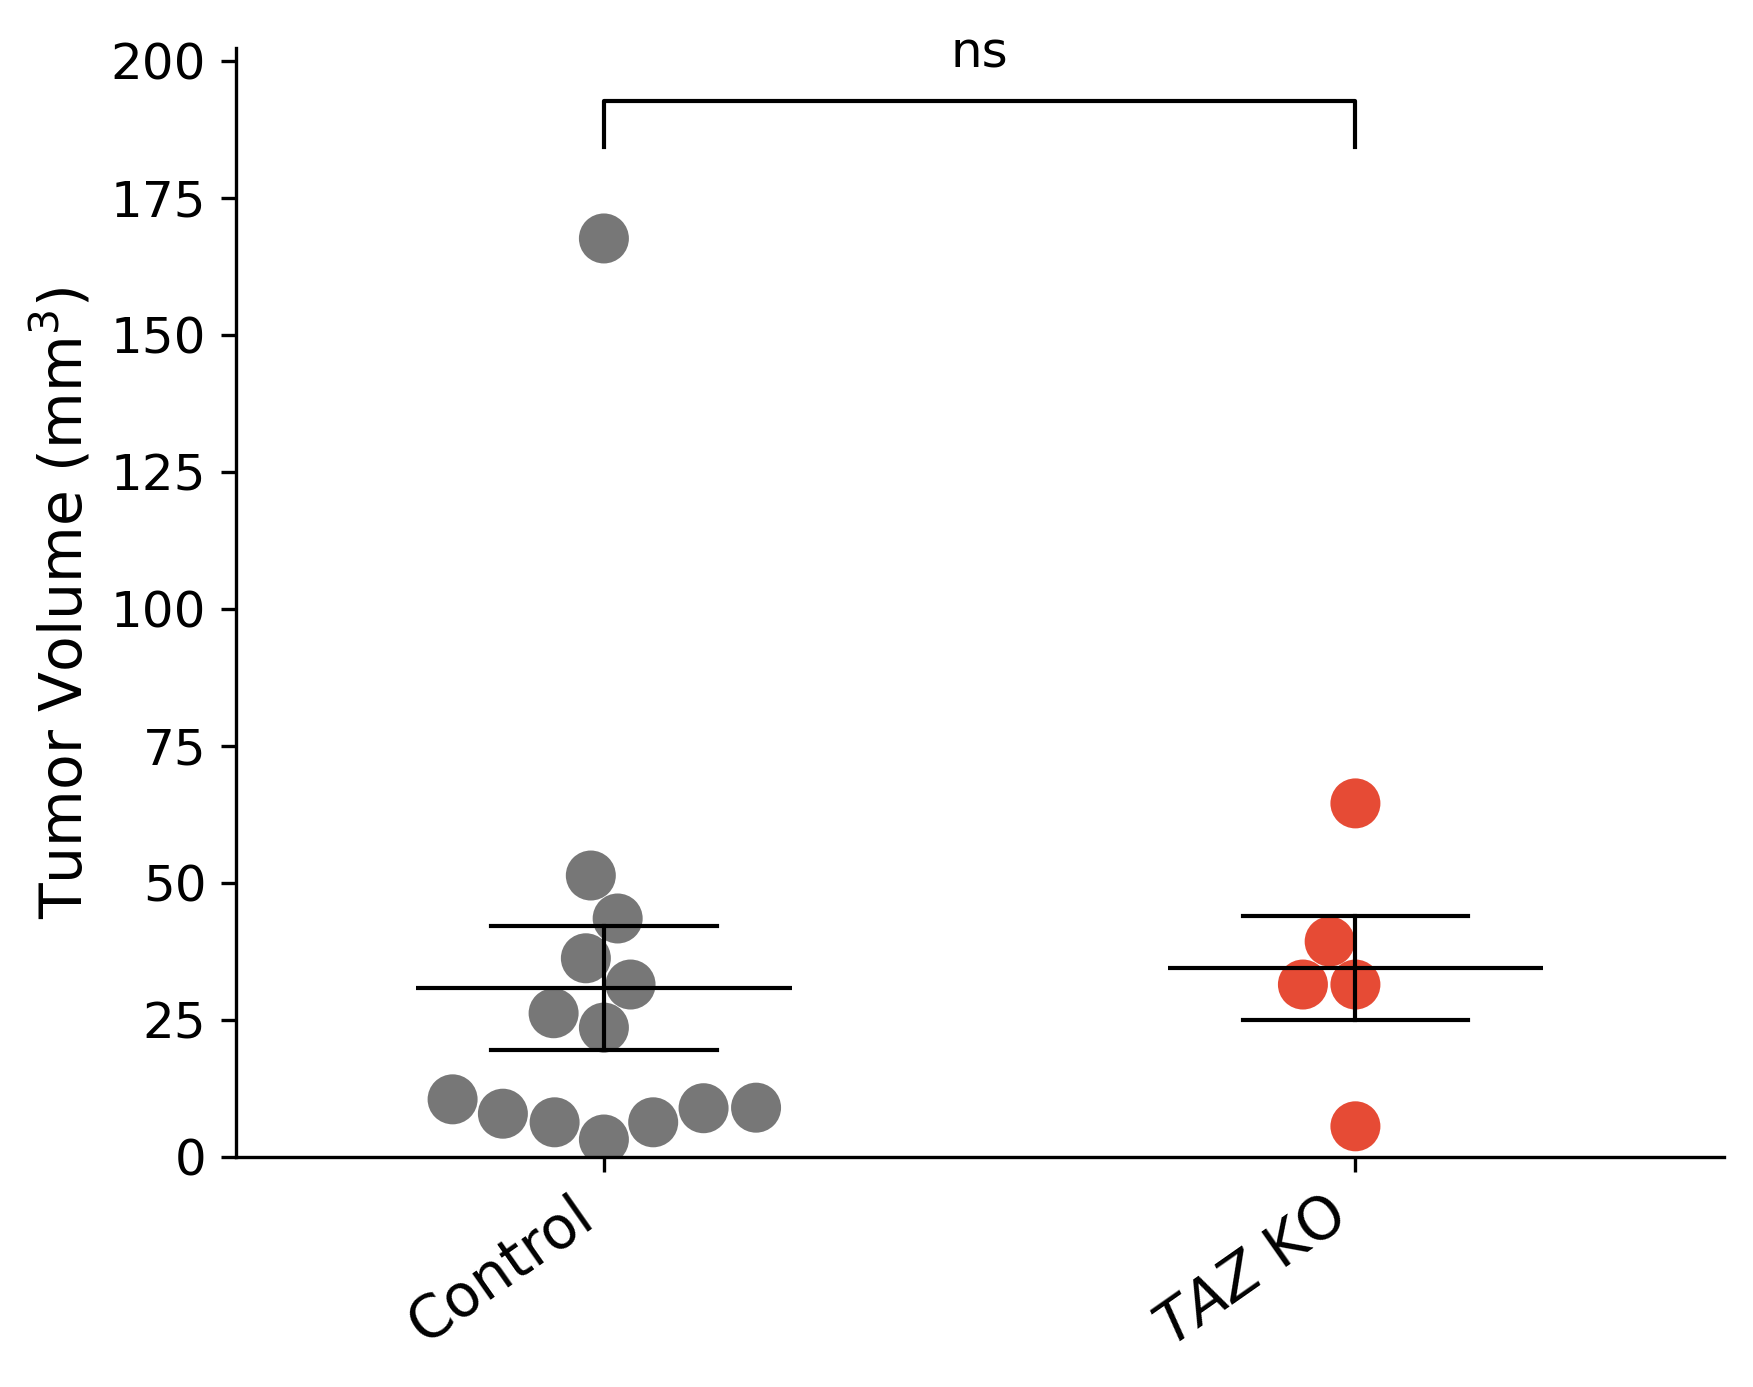

In [71]:
#We can also analyze our volumes easily using our function as well
swarm_analysis(
    dataset=tumor_data[['control_volume', 'tazko_volume']], 
    y_axislabel='Tumor Volume (mm$^3$)', 
    x_ticklabel=['Control', '$TAZ$ KO'], 
    figure_name='Xenograft_tumor_volume_analysis',
)

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #5 - Analyze nominal data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 800px;"></hr>

As you can see in our xenograft dataset, we have qualitative data as well, where we are evaluating whether or not the xenograft successfully engrafted onto our Nude mice. Currently, the dataset is the raw observations, and we want to determine what the counts are for each condition to be able to evaluate whether there is a difference in engraftment when we KO TAZ.

<h2>Count data</h2>

To count values within our DataFrame, we can make use of the <code>pd.Series.value_counts()</code> function. <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html" rel="noopener noreferrer"><u>Documentation for <code>pd.Series.value_counts()</code> can be found here.</u></a>

From our DataFrame, you'll need to pull the column containing the values you want to count, and then you can call up the <code>pd.Series.value_counts()</code> function to count all the values. Give that a try for the <code>'control_engraftment'</code> values and then the <code>'tazko_engraftment'</code> values.

In [72]:
#We can specify the column we wan to count from, and then count each value
#In this case, it'll count based on whether it is 'engraft' or 'not_engraft'
tumor_data['control_engraftment'].value_counts()

engraft        14
not_engraft     6
Name: control_engraftment, dtype: int64

In [73]:
tumor_data['tazko_engraftment'].value_counts()

not_engraft    15
engraft         5
Name: tazko_engraftment, dtype: int64

<h2>Assemble value counts into a DataFrame</h2>

To perform our statistical analyses, our counts will need to be in a 2x2 contingency table that resembles the below:

<table style="margin-left: 0px;">
    <tr>
        <td style="background-color: None; border: None;">&nbsp;</tD>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">'control_engraftment'</td>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">'tazko_engraftment'</td>
    </tr>
    <tr>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">'engraft'</td>
        <td style="background-color: #FFFFFF; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">14</td>
        <td style="background-color: #FFFFFF; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">5</td>
    </tr>
    <tr>
        <td style="background-color: #EEEEEE; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">'not_engraft'</td>
        <td style="background-color: #FFFFFF; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">6</td>
        <td style="background-color: #FFFFFF; border: 1px solid; border-color: #000000; width: 75px; text-align: center;">15</td>
    </tr>
</table>

See if you can use <code>pd.DataFrame()</code> to set up our contingency table.

In [74]:
#We can then set up a dictionary to create a DataFrame using those values to get our contingency table
engraft_table = pd.DataFrame(
    {'control_engraftment': tumor_data['control_engraftment'].value_counts(),
     'tazko_engraftment': tumor_data['tazko_engraftment'].value_counts(),
    },
)

Let's do a quick sanity check to make sure our contingency table was set up correctly.

In [75]:
engraft_table

,control_engraftment,tazko_engraftment
engraft,14,5
not_engraft,6,15


<h2>Perform a chi-squared test of independence</h2>

One way we can test nominal data is through a chi-squared test of independence. This test's null hypothesis is that the observed proportions of one group is equal to the observed proportions of another group. In our case, the null hypothesis would be that the proportion of engrafted and non-engrafted control samples is equal to the proportion for KO samples.

We will use our 2x2 contingency table that we set up to determine the chi-squared test statistic. Similar to both the t-test statistic, the chi-squared test statistic is used to determine the p-value. We will make use of the <code>stats.chi2_contingency()</code> function to perform our chi-squared test of independence. <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html" rel="noopener noreferrer"><u>Documentation for <code>stats.chi2_contingency()</code> function can be found here.</code>

We can just pass our contingency table to the function, and then pull out the pvalue from the output that we saved to a variable.

In [76]:
#And with our contingency table, we can make use of scipy.stats to run a chi-sq test of independence
chi_result = stats.chi2_contingency(engraft_table)

Like with before, have Python output whether or not the difference is significant.

In [77]:
#And we can pull out the pvalue to see if we have a significant difference between our two conditions
chi_result.pvalue

0.011309406711493062

<h2>Perform a Fisher's exact test</h2>

We can also make use of the Fisher's exact test to perform pair-wise comparisons between nominal data. This is generally recommended especially if your sample sizes are small. And the set up is the same as the one we used for the chi-squared test of independence, so we can use the same contingency table. We'll use the <code>stats.fisher_exact()</code> function this time. <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisher_exact.html" rel="noopener noreferrer"><u>Documentation for <code>stats.fisher_exact()</code> can be found here.</u></a>

This function is restricted to a 2x2 contingency table, and the null hypothesis is that the proportions are equal between the two nominal variables. It will output a result that contains two attributes, the odds ratio and the p-value, like our previous statistical tests. And among them, we can pull the pvalue attribute out of the variable to which we assigned our results.

In [78]:
#We can use that same contingency table to run a Fisher's exact test as well
fisher_result = stats.fisher_exact(engraft_table)

Let's make a quick modification to our chi-squared code to get Python to output whether or not our difference is significant based on our Fisher's exact test results.

In [79]:
#And like with previous statistical tests, we can pull out the pvalue
fisher_result.pvalue

0.010386702198860637

<h2>Plot a stacked bar plot</h2>

As you know from your lab reports, we can visualize our tumor engraftment data as a stacked bar plot. While <code>seaborn</code> has been helpful for us to plot swarmplots, <code>matplotlib</code> has the functionality for us to plot a stacked bar plot by taking advantage of its <code>plt.bar()</code> function. Recall from our earlier data visualization notebooks that we used this function to set up a simple bar plot, and now we'll use it to set up a stacked bar plot. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html" rel="noopener noreferrer"><u>Documentation for <code>plt.bar()</code> can be found here.</u></a>

If you dig into the documentation:

```python
plt.bar(x, height, width=0.8, bottom=None, *, align='center', data=None, **kwargs)
```

You can see that there is a <code>bottom</code> parameter, which we left as the default before. This parameter sets the bottom of where a bar will go, and as a result, we can use it to stack bars one on top of another.

<h3>Set up contingency table for plotting</h3>

To make things a little easier for us when plotting, let's first convert our counts to a percentage of the total counts for each sample group. This will ensure that bars for our two sample groups add up to the same total height (100%).

We'll first use <code>pd.DataFrame.sum()</code> to find the total counts for each sample group, then we can use <code>pd.DataFrame.div()</code> to divide our counts by their respective sample group's total counts.

<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.sum()</code> can be found here.</u></a>

<a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.div.html" rel="noopener noreferrer"><u>Documentation for <code>pd.DataFrame.div()</code> can be found here.</u></a>

In [80]:
#Let's convert our counts into percentages
engraft_table_percent = engraft_table.div(engraft_table.sum(axis=0), axis=1)
engraft_table_percent *= 100

In [81]:
#And we can take a look to see how the result looks like
engraft_table_percent

,control_engraftment,tazko_engraftment
engraft,70.0,25.0
not_engraft,30.0,75.0


Then we can transpose our DataFrame to make it easier to create a stacked bar plot.

In [82]:
#To make things easier for plotting, we can transpose our DataFrame
engraft_table_T = engraft_table_percent.T
engraft_table_T

,engraft,not_engraft
control_engraftment,70.0,30.0
tazko_engraftment,25.0,75.0


We can also do all that in a single line.

In [83]:
#This cell here accomplishes the same thing just within a single line
engraft_table_T = engraft_table.div(engraft_table.sum(axis=0), axis=1).T * 100

Let's do a quick sanity check.

In [84]:
engraft_table_T

,engraft,not_engraft
control_engraftment,70.0,30.0
tazko_engraftment,25.0,75.0


<h3>Plot a stacked bar plot</h3>

Let's now set up our stacked bar plot using our calculated percentage values in our 2x2 contingency table.

<BarContainer object of 2 artists>

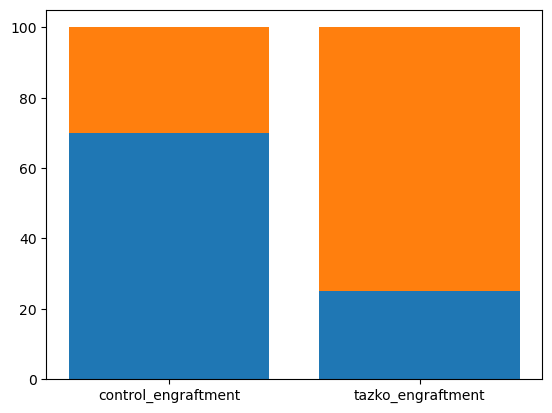

In [86]:
#Set up our plot in the usual way
fig, ax = plt.subplots()

#Plot our first bar plot, which is set at the bottom of the y-axis
plt.bar(
    engraft_table_T.index,
    engraft_table_T.loc[:, 'engraft'],
)

#Then we plot our second bar plot, which will sit on top of first bar plot
plt.bar(
    engraft_table_T.index,
    engraft_table_T.loc[:, 'not_engraft'],
    bottom=engraft_table_T.loc[:, 'engraft'],  #Which is why we pass an argument to the bottom parameter based on the heights of the first bar plot
)

#You should then see that you have a stacked bar plot

#And you can pretty up the plot as needed based on how we've done so previously